## Dataset Information
**Additional Information**

Seven different types of dry beans were used in this research, taking into account the features such as form, shape, type, and structure by the market situation. A computer vision system was developed to distinguish seven different registered varieties of dry beans with similar features in order to obtain uniform seed classification. For the classification model, images of 13,611 grains of 7 different registered dry beans were taken with a high-resolution camera. Bean images obtained by computer vision system were subjected to segmentation and feature extraction stages, and a total of 16 features; 12 dimensions and 4 shape forms, were obtained from the grains.



1. Area (A): The area of a bean zone and the number of pixels within its boundaries.
2. Perimeter (P): Bean circumference is defined as the length of its border.
3. Major axis length (L): The distance between the ends of the longest line that can be drawn from a bean.
4. Minor axis length (l): The longest line that can be drawn from the bean while standing perpendicular to the main axis.
5. Aspect ratio (K): Defines the relationship between L and l.
6. Eccentricity (Ec): Eccentricity of the ellipse having the same moments as the region.
7. Convex area (C): Number of pixels in the smallest convex polygon that can contain the area of a bean seed.
8. Equivalent diameter (Ed): The diameter of a circle having the same area as a bean seed area.
9. Extent (Ex): The ratio of the pixels in the bounding box to the bean area.
10. Solidity (S): Also known as convexity. The ratio of the pixels in the convex shell to those found in beans.
11. Roundness (R): Calculated with the following formula: (4piA)/(P^2)
12. Compactness (CO): Measures the roundness of an object: Ed/L
13. ShapeFactor1 (SF1)
14. ShapeFactor2 (SF2)
15. ShapeFactor3 (SF3)
16. ShapeFactor4 (SF4)
17. Class (Seker, Barbunya, Bombay, Cali, Dermosan, Horoz and Sira)

[DataSet](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset)

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# metrics and
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
# models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


In [39]:
df = pd.read_csv("https://raw.githubusercontent.com/MachineLearningBCAM/Datasets/refs/heads/main/data/multi_class_datasets/dry_bean_dataset.csv")
df.head(5)

,28395,610.291,208.1781167,173.888747,1.197191424,0.549812187,28715,190.1410973,0.763922518,0.988855999,0.958027126,0.913357755,0.007331506,0.003147289,0.834222388,0.998723889,SEKER
0,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
1,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
2,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
3,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
4,30279,634.927,212.560556,181.510182,1.171067,0.520401,30600,196.347702,0.775688,0.989510,0.943852,0.923726,0.007020,0.003153,0.853270,0.999236,SEKER


In [40]:
df.columns

Index(['28395', '610.291', '208.1781167', '173.888747', '1.197191424',
       '0.549812187', '28715', '190.1410973', '0.763922518', '0.988855999',
       '0.958027126', '0.913357755', '0.007331506', '0.003147289',
       '0.834222388', '0.998723889', 'SEKER'],
      dtype='object')

In [41]:
columns = ["Area",
'Perimeter',
'Major_axis_length',
'Minor_axis_length',
'Aspect_ratio',
'Eccentricity',
'Convex_area',
'Equivalent_diameter',
'Extent',
'Solidity',
'Roundness',
'Compactness',
'ShapeFactor1',
'ShapeFactor2',
'ShapeFactor3',
'ShapeFactor4',
'Class']

In [42]:
df.columns = columns

In [43]:
df.head()

,Area,Perimeter,Major_axis_length,Minor_axis_length,Aspect_ratio,Eccentricity,Convex_area,Equivalent_diameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
1,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
2,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
3,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
4,30279,634.927,212.560556,181.510182,1.171067,0.520401,30600,196.347702,0.775688,0.989510,0.943852,0.923726,0.007020,0.003153,0.853270,0.999236,SEKER


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13610 entries, 0 to 13609
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Area                 13610 non-null  int64  
 1   Perimeter            13610 non-null  float64
 2   Major_axis_length    13610 non-null  float64
 3   Minor_axis_length    13610 non-null  float64
 4   Aspect_ratio         13610 non-null  float64
 5   Eccentricity         13610 non-null  float64
 6   Convex_area          13610 non-null  int64  
 7   Equivalent_diameter  13610 non-null  float64
 8   Extent               13610 non-null  float64
 9   Solidity             13610 non-null  float64
 10  Roundness            13610 non-null  float64
 11  Compactness          13610 non-null  float64
 12  ShapeFactor1         13610 non-null  float64
 13  ShapeFactor2         13610 non-null  float64
 14  ShapeFactor3         13610 non-null  float64
 15  ShapeFactor4         13610 non-null 

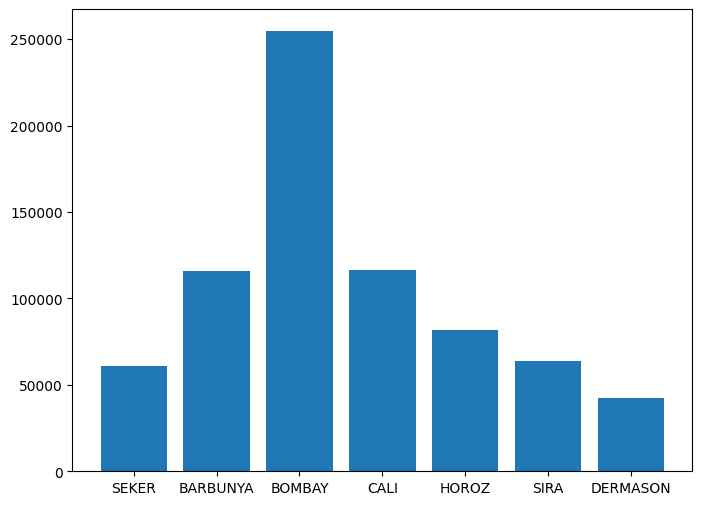

In [45]:
plt.figure(figsize=(8,6))
plt.bar(df['Class'], df['Area'])
plt.show()

In [46]:
df['Class'].value_counts()

,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2026
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


In [47]:
df['Class'] = df['Class'].replace({"DERMASON":1,"SIRA":2,"SEKER":3,"HOROZ":4,"CALI":5,"BARBUNYA": 6,"BOMBAY": 7})

/tmp/ipykernel_56383/887774556.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Class'] = df['Class'].replace({"DERMASON":1,"SIRA":2,"SEKER":3,"HOROZ":4,"CALI":5,"BARBUNYA": 6,"BOMBAY": 7})


In [48]:
df['Class']

,Class
0,3
1,3
2,3
3,3
4,3
...,...
13605,1
13606,1
13607,1
13608,1


In [49]:
#Bunday qilish kerak emas !!!!!!
# encodeing = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
# encod = encodeing.fit_transform(df[['Class']])+++++
# encod

In [50]:
# df = df.join(encod)
# df.drop('Class', axis=1, inplace=True)
# df.head()

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13610 entries, 0 to 13609
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Area                 13610 non-null  int64  
 1   Perimeter            13610 non-null  float64
 2   Major_axis_length    13610 non-null  float64
 3   Minor_axis_length    13610 non-null  float64
 4   Aspect_ratio         13610 non-null  float64
 5   Eccentricity         13610 non-null  float64
 6   Convex_area          13610 non-null  int64  
 7   Equivalent_diameter  13610 non-null  float64
 8   Extent               13610 non-null  float64
 9   Solidity             13610 non-null  float64
 10  Roundness            13610 non-null  float64
 11  Compactness          13610 non-null  float64
 12  ShapeFactor1         13610 non-null  float64
 13  ShapeFactor2         13610 non-null  float64
 14  ShapeFactor3         13610 non-null  float64
 15  ShapeFactor4         13610 non-null 

In [52]:
df.corrwith(df['Class']).abs().sort_values(ascending=False)

,0
Class,1.000000
Perimeter,0.858282
Equivalent_diameter,0.835526
ShapeFactor1,0.817502
Major_axis_length,0.815907
Minor_axis_length,0.784398
Convex_area,0.773996
Area,0.772491
ShapeFactor2,0.637555
Roundness,0.559003


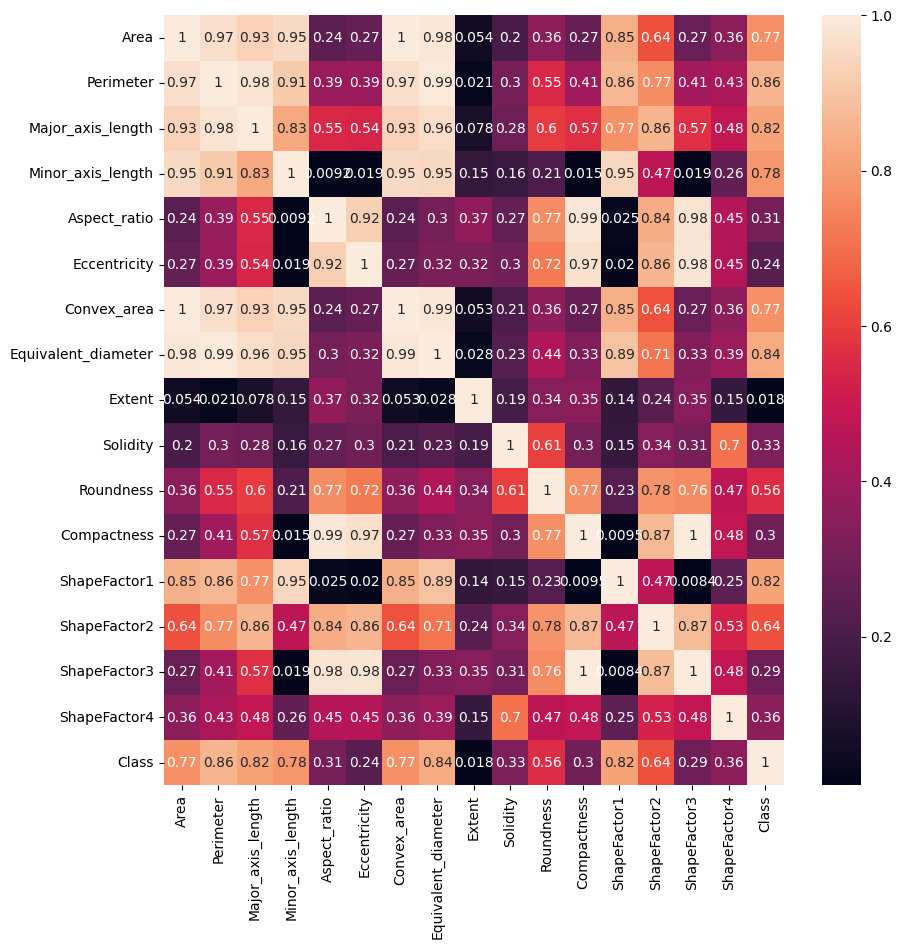

In [53]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr().abs(),annot=True)
plt.show()

In [54]:
X = df.drop("Class", axis=1)
y = df['Class']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, train_size=0.8)
standars_s = StandardScaler()
X_train = standars_s.fit_transform(X_train)
X_test = standars_s.fit_transform(X_test)


In [56]:
X_train

array([[-0.58500363, -0.80453692, -0.9090345 , ...,  1.35550549,
         1.36379809,  0.91668618],
       [ 0.09730259,  0.48453612,  0.81379175, ..., -1.29660889,
        -1.76772884,  0.43000765],
       [ 0.32443942,  0.56019441,  0.19216034, ..., -0.12833218,
         0.59162453,  0.73013166],
       ...,
       [ 1.27739434,  1.36668588,  1.45460546, ..., -1.15485928,
        -0.62254522, -0.9100787 ],
       [-0.49946128, -0.69717245, -0.88191188, ...,  1.52139496,
         1.74924892,  0.85010166],
       [ 0.36912264,  0.65910547,  1.01577699, ..., -1.292444  ,
        -1.54542074, -1.04508659]])

All models \
`from sklearn.neighbors import KNeighborsClassifier` \
`from sklearn.tree import DecisionTreeClassifier`\
`from sklearn.svm import SVC`\
`from sklearn.naive_bayes import GaussianNB `

In [57]:
#KNeighborsClassifier
knn_models = KNeighborsClassifier(n_neighbors=6)
knn_models.fit(X_train, y_train)
knn = knn_models.predict(X_test)
knn_p = accuracy_score(y_test,knn)
print("KNeighborsClassifier model accuracy : ", knn_p)

KNeighborsClassifier model accuracy :  0.9309331373989713


In [58]:
#Choose correct the best value for n

In [59]:

f = []
for i in range(1,25):
  knn_ch = KNeighborsClassifier(n_neighbors=i)
  knn_ch.fit(X_train, y_train)
  knn = knn_ch.predict(X_test)
  f.append(accuracy_score(y_test,knn))
  print("--"*37)
  print(f"KNeighborsClassifier model accuracy for n equal at {i}:", f[-1])

--------------------------------------------------------------------------
KNeighborsClassifier model accuracy for n equal at 1: 0.9155033063923586
--------------------------------------------------------------------------
KNeighborsClassifier model accuracy for n equal at 2: 0.9177075679647319
--------------------------------------------------------------------------
KNeighborsClassifier model accuracy for n equal at 3: 0.9279941219691403
--------------------------------------------------------------------------
KNeighborsClassifier model accuracy for n equal at 4: 0.9272593681116826
--------------------------------------------------------------------------
KNeighborsClassifier model accuracy for n equal at 5: 0.9313005143277002
--------------------------------------------------------------------------
KNeighborsClassifier model accuracy for n equal at 6: 0.9309331373989713
--------------------------------------------------------------------------
KNeighborsClassifier model accuracy f

----------------------------------------
| The best n negihbor number this is 6 |
----------------------------------------


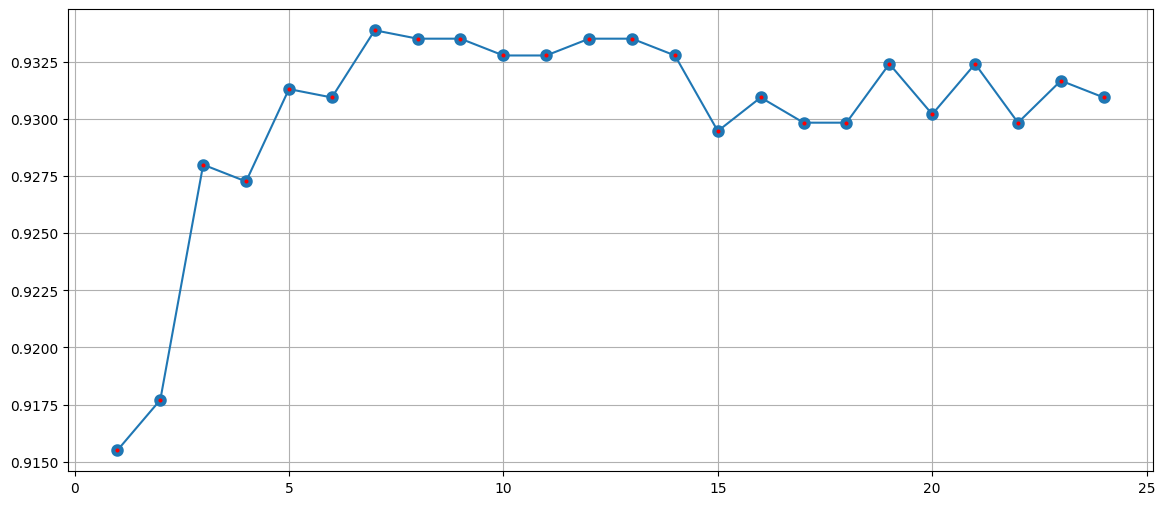

In [60]:
print("--"*20)
print(f"| The best n negihbor number this is {f.index(max(f))} |")
print("--"*20)
plt.figure(figsize=(14,6))
plt.plot(range(1,25),f,  marker="o", mfc='r', mew=3)
plt.grid()
plt.show()

In [61]:

#DecisionTreeClassifier
Dtr_models = DecisionTreeClassifier(max_depth=10)
Dtr_models.fit(X_train, y_train)
Dtr = Dtr_models.predict(X_test)
Dtr_p = accuracy_score(y_test,knn)
print("DecisionTreeClassifier model accuracy : ", Dtr_p)

DecisionTreeClassifier model accuracy :  0.9309331373989713


In [62]:
# model_Dtr = DecisionTreeClassifier()

# param_grid = {
#     'max_depth': range(1,5),
#     'min_samples_split': range(1,5),
#     'min_samples_leaf': range(1,5),
#     'criterion': ['gini', 'entropy']
# }

# grid_model = GridSearchCV(estimator=model_Dtr, param_grid=param_grid, cv=5, scoring='accuracy' )

# grid_model.fit(X_train, y_train)



In [64]:
# print("Optimal parameters:", grid_model.best_params_)

In [65]:
#DecisionTreeClassifier
SVC_models = SVC()
SVC_models.fit(X_train, y_train)
SVC = Dtr_models.predict(X_test)
SVC_p = accuracy_score(y_test,SVC)
print("DecisionTreeClassifier model accuracy : ", SVC_p)

DecisionTreeClassifier model accuracy :  0.9074210139603233


In [66]:
x = [knn_p, Dtr_p,SVC_p]
x

[0.9309331373989713, 0.9309331373989713, 0.9074210139603233]

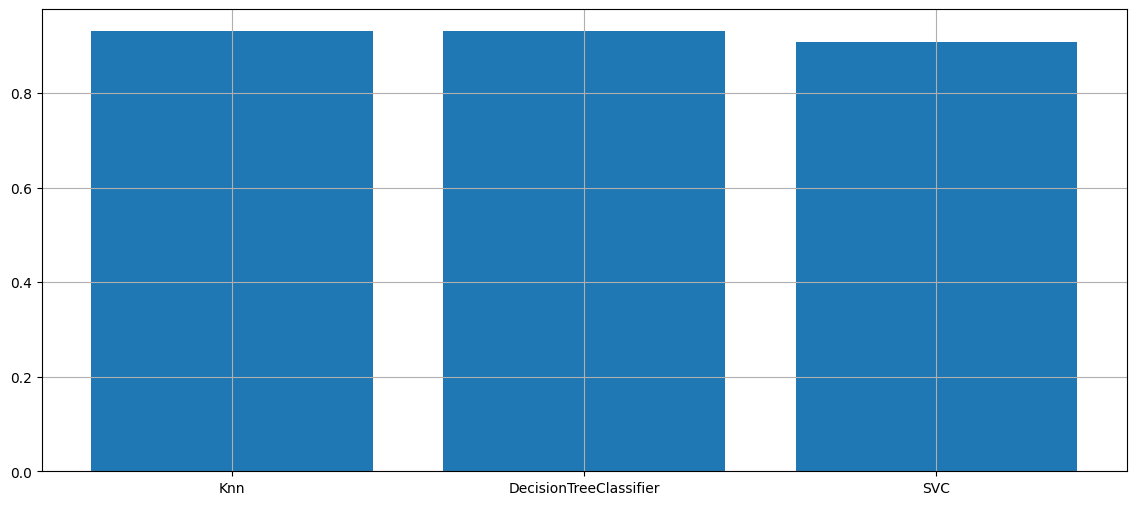

In [67]:
x = [knn_p, Dtr_p,SVC_p]
plt.figure(figsize=(14,6))
plt.bar(["Knn", "DecisionTreeClassifier", "SVC"], x)
plt.grid()
plt.show()